In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
file_path = r"C:\Users\singh\Downloads\561 file for ML Model.xlsx"

df = pd.read_excel(file_path)

print("\n========== DATASET INFORMATION ==========")
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())


========== DATASET INFORMATION ==========
Dataset Shape : (560, 30)

Columns:
['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti', 'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*', 'UTS (MPa)', 'YS (MPa)', 'Total Elongation (%)', 'Engg. Strain', 'n-Value']


In [3]:
df["UTS_YS_Ratio"] = df["UTS (MPa)"] / df["YS (MPa)"]

print(df["UTS_YS_Ratio"].isna().sum())
print(df["UTS_YS_Ratio"].isnull().sum())

6
6


In [4]:
import numpy as np

print(np.isinf(df["UTS_YS_Ratio"]).sum())

0


In [5]:
df["UTS_YS_Ratio"] = df["UTS (MPa)"] / df["YS (MPa)"]

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(subset=["UTS_YS_Ratio"])

In [6]:
print(df[df["YS (MPa)"] <= 0])

print(df["YS (MPa)"].describe())

print(df["UTS_YS_Ratio"].isna().sum())

print(np.isinf(df["UTS_YS_Ratio"]).sum())

Empty DataFrame
Columns: [C, Mn, Si, Al, B, N, Ca, P, Ni, S, Cr, Mo, Ti, V, Nb, Ni.1, Zn, Cu, Sn, W, Co, Zr, O, Mg, Ti*, UTS (MPa), YS (MPa), Total Elongation (%), Engg. Strain, n-Value, UTS_YS_Ratio]
Index: []

[0 rows x 31 columns]
count     554.000000
mean      496.359206
std       175.966941
min       165.000000
25%       350.000000
50%       475.000000
75%       605.000000
max      1135.000000
Name: YS (MPa), dtype: float64
0
0


In [7]:
X = df.drop(columns=[
    "UTS (MPa)",
    "YS (MPa)",
    "UTS_YS_Ratio",
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
])

y = df["UTS_YS_Ratio"]

In [8]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== DATA SPLIT ==========")

print(
    "Training Samples :",
    X_train.shape[0]
)

print(
    "Validation Samples :",
    X_validation.shape[0]
)


========== DATA SPLIT ==========
Training Samples : 443
Validation Samples : 111


In [9]:
X_scaler = StandardScaler()

y_scaler = StandardScaler()


X_train_scaled = X_scaler.fit_transform(
    X_train
)


X_validation_scaled = X_scaler.transform(
    X_validation
)


y_train = y_train.values.reshape(-1,1)
y_validation = y_validation.values.reshape(-1,1)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train).ravel()

In [10]:
model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.01
)

model.fit(
    X_train_scaled,
    y_train_scaled
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [11]:
y_pred_scaled = model.predict(X_validation_scaled)

y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1,1)
)

In [12]:
mse = mean_squared_error(
    y_validation,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_validation,
    y_pred
)

r2 = r2_score(
    y_validation,
    y_pred
)

print("\n========== UTS/YS RATIO RESULT ==========")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


========== UTS/YS RATIO RESULT ==========
MSE : 0.03259448971788225
RMSE: 0.18053944089279286
MAE : 0.12753087952593387
R2  : 0.503770963364872


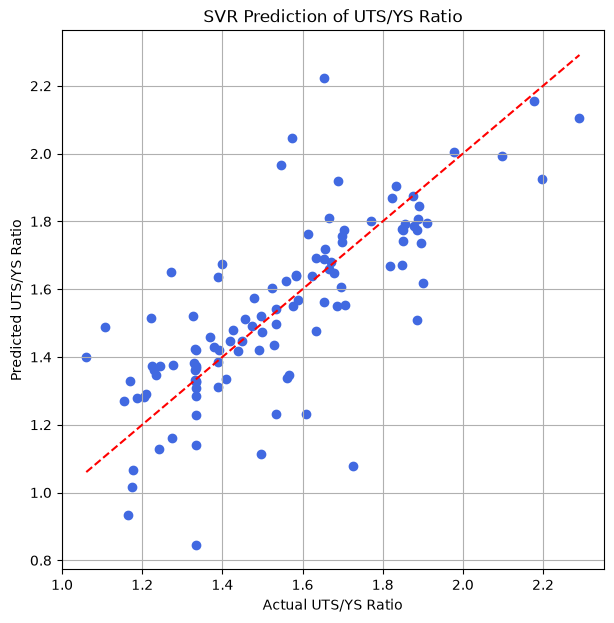

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_validation,
    y_pred,
    color="royalblue"
)

plt.plot(
    [y_validation.min(), y_validation.max()],
    [y_validation.min(), y_validation.max()],
    "r--"
)

plt.xlabel("Actual UTS/YS Ratio")
plt.ylabel("Predicted UTS/YS Ratio")
plt.title("SVR Prediction of UTS/YS Ratio")
plt.grid(True)

plt.show()